# ML Intro: Assignment 2

## Titanic Survival Analysis with Logistic Regression

This code looks at the Titanic dataset, cleans the information,
creates a logistic regression model,
evaluates the model, and experiments just a bit with feature engineering.

## First, we import libraries and all the tools needed for data analysis, charts, and machine learning.

In [1]:
# First, we import libraries and
# all the tools needed for data analysis, charts, and machine learning.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Here we set the same clean chart style
# that is gonna run throughout the whole assignment.
sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)

## Then we load the Titanic dataset:

In [2]:
# Then we load the Titanic dataset:

# First, we need to look for the CSV file in the same folder as this program.
# If it is not there, then we need to download the same data used by the class notebook.
local_files = [
    Path("Titanic-Dataset.csv"),
    Path("outputs") / "Titanic-Dataset.csv",
]

data_file = next((path for path in local_files if path.exists()), None)

if data_file is not None:
    train = pd.read_csv(data_file)
    data_source = str(data_file)
else:
    data_url = (
        "https://raw.githubusercontent.com/niteen11/"
        "data301_predictive_analytics_machine_learning/"
        "main/data/titanic_train.csv"
    )
    train = pd.read_csv(data_url)
    data_source = data_url


# Make 100% sure the correct dataset was loaded.
# And yes, I checked, it is a correct dataset.
expected_columns = {
    "PassengerId",
    "Survived",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked",
}

assert expected_columns.issubset(train.columns), (
    "The Titanic file is missing expected columns."
)

print("\nTITANIC DATASET")
print(f"Loaded from: {data_source}")
print(f"Rows: {train.shape[0]}")
print(f"Columns: {train.shape[1]}")


TITANIC DATASET
Loaded from: Titanic-Dataset.csv
Rows: 891
Columns: 12


## Here I am previewing the data:

In [3]:
# Here I am previewing the data:
# 1. Each row represents one Titanic passenger.
# 2. "Survived" is the value the model will try to predict:
# 0 means the passenger did not survive.
# 1 means the passenger survived.
print("\nFIRST FIVE PASSENGERS")
print(train.head().to_string())


FIRST FIVE PASSENGERS
   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket    Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.250   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.283   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.925   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.100  C123        S
4            5         0       3                             Allen, Mr. William Henry    male  35.0      0      0            373450   8.050   NaN        S


## Check missing values:

In [4]:
# Check missing values:
# The code does that by counting
# the missing values and calculating the percentage missing.
missing_values = pd.DataFrame(
    {
        "Missing values": train.isna().sum(),
        "Percent missing": train.isna().mean().mul(100),
    }
)

print("\nMISSING VALUES")
print(
    missing_values
    .sort_values("Missing values", ascending=False)
    .to_string()
)

# So, what we are observing here:
# "Cabin" is missing for most passengers. Age is missing for about one fifth
# of the passengers, while "Embarked" is missing only twice.
# "Cabin" will not be used in the model.
# The missing values will be filled by the preprocessing pipeline.


MISSING VALUES
             Missing values  Percent missing
Cabin                   687           77.104
Age                     177           19.865
Embarked                  2            0.224
PassengerId               0            0.000
Survived                  0            0.000
Pclass                    0            0.000
Name                      0            0.000
Sex                       0            0.000
SibSp                     0            0.000
Parch                     0            0.000
Ticket                    0            0.000
Fare                      0            0.000


## Plot the missing values:

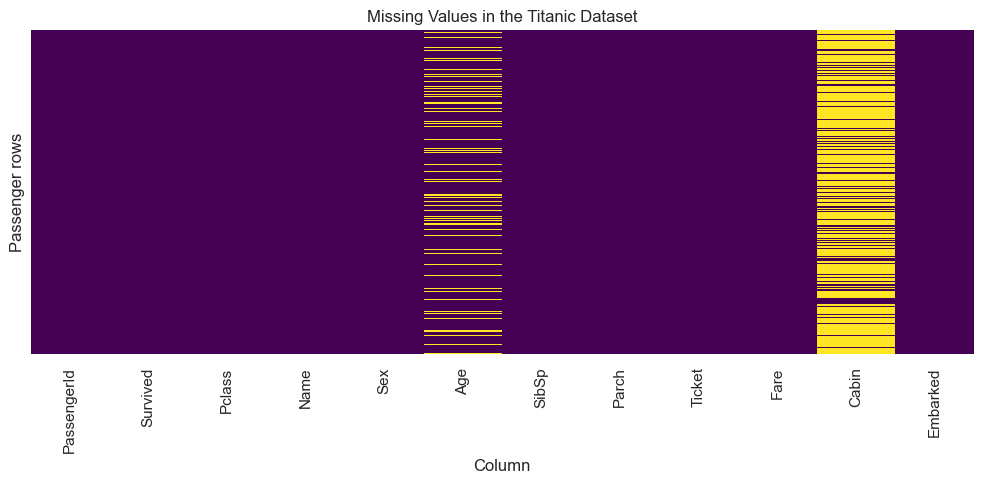


Missing-value chart interpretation:
Cabin information is missing from most rows. Missing ages are also spread throughout the dataset. Nearly all embarkation values are present.


In [5]:
# Plot the missing values:
# Yellow marks show where information is missing.
plt.figure(figsize=(10, 5))

sns.heatmap(
    train.isna(),
    yticklabels=False,
    cbar=False,
    cmap="viridis",
)

plt.title("Missing Values in the Titanic Dataset")
plt.xlabel("Column")
plt.ylabel("Passenger rows")
plt.tight_layout()
plt.show()

print(
    "\nMissing-value chart interpretation:\n"
    "Cabin information is missing from most rows. Missing ages are also "
    "spread throughout the dataset. Nearly all embarkation values are present."
)

## Overall survival:

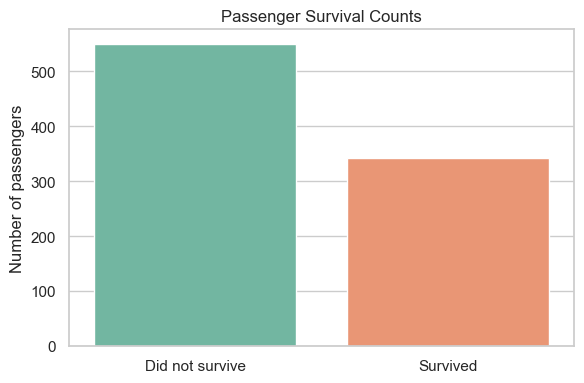


SURVIVAL COUNTS
Survived
Did not survive    549
Survived           342
Overall survival rate: 38.4%

Survival chart interpretation:
More passengers died than survived. About 38% of the passengers in this dataset survived.


In [6]:
# Overall survival:
# Count the number of passengers in the two outcome groups.
plt.figure(figsize=(6, 4))

survival_plot = sns.countplot(
    data=train,
    x="Survived",
    hue="Survived",
    palette="Set2",
    legend=False,
)

survival_plot.set_xticks(
    [0, 1],
    ["Did not survive", "Survived"],
)

survival_plot.set_title("Passenger Survival Counts")
survival_plot.set_xlabel("")
survival_plot.set_ylabel("Number of passengers")

plt.tight_layout()
plt.show()

survival_counts = train["Survived"].value_counts().sort_index()
survival_rate = train["Survived"].mean()

print("\nSURVIVAL COUNTS")

print(
    survival_counts.rename(
        index={
            0: "Did not survive",
            1: "Survived",
        }
    ).to_string()
)

print(f"Overall survival rate: {survival_rate:.1%}")

print(
    "\nSurvival chart interpretation:\n"
    "More passengers died than survived. About 38% of the passengers "
    "in this dataset survived."
)

## Survival by sex:

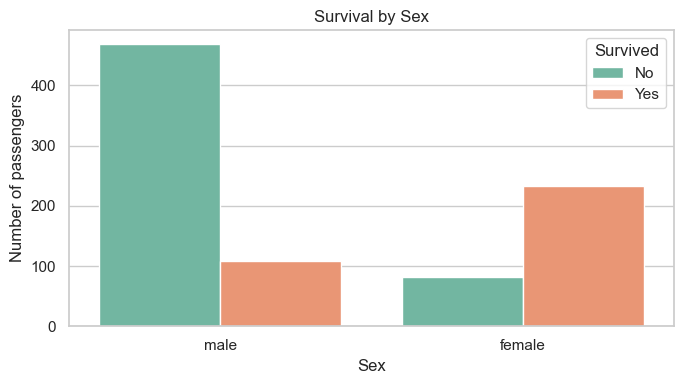


SURVIVAL PERCENTAGE BY SEX
        Survival percent
Sex                     
female            74.204
male              18.891

Sex chart interpretation:
Female passengers had a much higher survival rate than male passengers: about 74% compared with about 19%. Sex is likely to be an important predictor in the model.


In [7]:
# Survival by sex:
# Compare survival counts for female and male passengers.
plt.figure(figsize=(7, 4))

sns.countplot(
    data=train,
    x="Sex",
    hue="Survived",
    palette="Set2",
)

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"],
)

plt.tight_layout()
plt.show()

survival_by_sex = (
    train.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

print("\nSURVIVAL PERCENTAGE BY SEX")

print(
    survival_by_sex
    .rename("Survival percent")
    .to_frame()
    .to_string()
)

print(
    "\nSex chart interpretation:\n"
    "Female passengers had a much higher survival rate than male "
    "passengers: about 74% compared with about 19%. Sex is likely "
    "to be an important predictor in the model."
)

## Survival by passenger class:

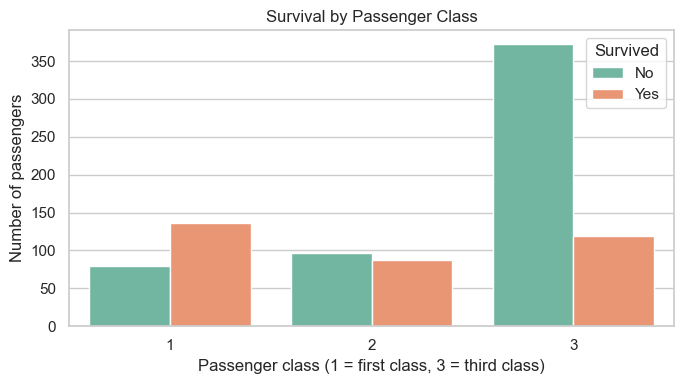


SURVIVAL PERCENTAGE BY CLASS
        Survival percent
Pclass                  
1                 62.963
2                 47.283
3                 24.236

Passenger-class chart interpretation:
Survival decreased as the class number increased. About 63% of first-class passengers survived, compared with 47% of second-class passengers and 24% of third-class passengers.


In [8]:
# Survival by passenger class:
# Compare survival for first-, second-, and third-class passengers.
plt.figure(figsize=(7, 4))

sns.countplot(
    data=train,
    x="Pclass",
    hue="Survived",
    palette="Set2",
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger class (1 = first class, 3 = third class)")
plt.ylabel("Number of passengers")

plt.legend(
    title="Survived",
    labels=["No", "Yes"],
)

plt.tight_layout()
plt.show()

survival_by_class = (
    train.groupby("Pclass")["Survived"]
    .mean()
    .mul(100)
)

print("\nSURVIVAL PERCENTAGE BY CLASS")

print(
    survival_by_class
    .rename("Survival percent")
    .to_frame()
    .to_string()
)

print(
    "\nPassenger-class chart interpretation:\n"
    "Survival decreased as the class number increased. About 63% of "
    "first-class passengers survived, compared with 47% of second-class "
    "passengers and 24% of third-class passengers."
)

## Here we are looking at the importance of age and siblings or spouses:

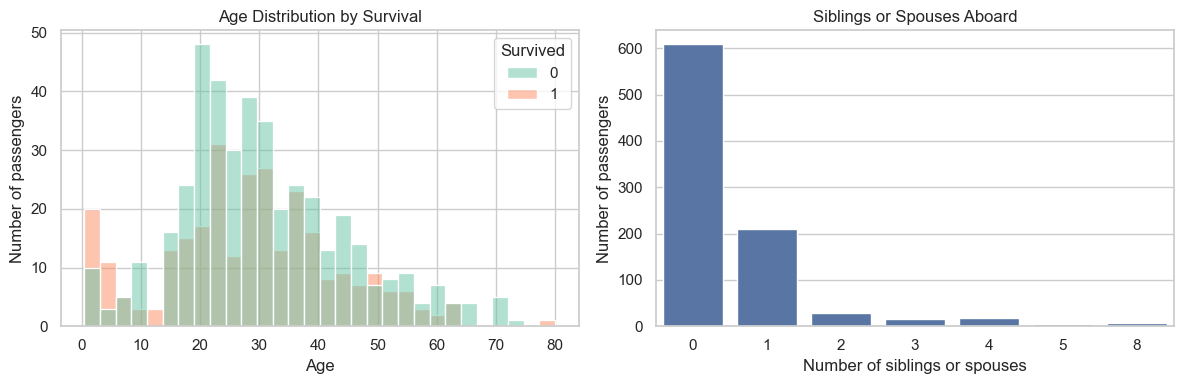


Age and family chart interpretation:
Most known ages are between about 18 and 40. The age distributions of survivors and non-survivors overlap, so age does not separate the groups as clearly as sex. Most passengers traveled with no sibling or spouse.


In [9]:
# Here we are looking at the importance of age and siblings or spouses:
# The first chart compares the ages of survivors and non-survivors.
# The second chart shows how many siblings or spouses passengers had aboard.
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    multiple="layer",
    alpha=0.5,
    palette="Set2",
    ax=axes[0],
)

axes[0].set_title("Age Distribution by Survival")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of passengers")

sns.countplot(
    data=train,
    x="SibSp",
    color="#4C72B0",
    ax=axes[1],
)

axes[1].set_title("Siblings or Spouses Aboard")
axes[1].set_xlabel("Number of siblings or spouses")
axes[1].set_ylabel("Number of passengers")

plt.tight_layout()
plt.show()

print(
    "\nAge and family chart interpretation:\n"
    "Most known ages are between about 18 and 40. The age distributions "
    "of survivors and non-survivors overlap, so age does not separate the "
    "groups as clearly as sex. Most passengers traveled with no sibling "
    "or spouse."
)

## Feature engineering:

In [10]:
# Feature engineering:
# Work on a copy so the original information stays unchanged.
model_data = train.copy()

# FamilySize combines the passenger, siblings or spouses, and
# parents or children into one family-group size.
model_data["FamilySize"] = (
    model_data["SibSp"]
    + model_data["Parch"]
    + 1
)

# IsAlone is 1 when the passenger had no listed family member aboard.
model_data["IsAlone"] = (
    model_data["FamilySize"] == 1
).astype(int)

print("\nENGINEERED FEATURES")

print(
    model_data[
        [
            "SibSp",
            "Parch",
            "FamilySize",
            "IsAlone",
        ]
    ]
    .head()
    .to_string()
)


ENGINEERED FEATURES
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1


## Survival by traveling alone:

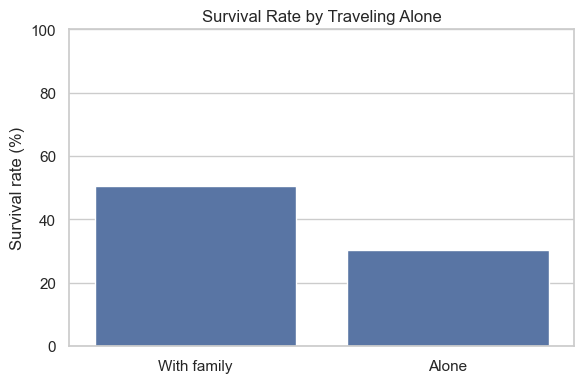


SURVIVAL PERCENTAGE BY TRAVEL GROUP
             Survival percent
IsAlone                      
With family            50.565
Alone                  30.354

Travel-group chart interpretation:
Passengers with a listed family member had a survival rate of about 51%. Passengers traveling alone had a survival rate of about 30%. This suggests that FamilySize and IsAlone may help the model.


In [11]:
# Survival by traveling alone:
# Compare passengers traveling alone with passengers who had family aboard.
alone_survival = (
    model_data.groupby("IsAlone")["Survived"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(6, 4))

alone_plot = sns.barplot(
    x=["With family", "Alone"],
    y=[
        alone_survival.loc[0],
        alone_survival.loc[1],
    ],
    color="#4C72B0",
)

alone_plot.set_title("Survival Rate by Traveling Alone")
alone_plot.set_xlabel("")
alone_plot.set_ylabel("Survival rate (%)")
alone_plot.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print("\nSURVIVAL PERCENTAGE BY TRAVEL GROUP")

print(
    alone_survival
    .rename(
        index={
            0: "With family",
            1: "Alone",
        }
    )
    .rename("Survival percent")
    .to_frame()
    .to_string()
)

print(
    "\nTravel-group chart interpretation:\n"
    "Passengers with a listed family member had a survival rate of about "
    "51%. Passengers traveling alone had a survival rate of about 30%. "
    "This suggests that FamilySize and IsAlone may help the model."
)

## Prepare the training and test rows:

In [12]:
# Prepare the training and test rows:
# Use the same training and test passengers for both models.
# Stratify keeps approximately the same class balance in both groups.
train_rows, test_rows = train_test_split(
    model_data.index,
    test_size=0.30,
    random_state=101,
    stratify=model_data["Survived"],
)

target = "Survived"

# These are the main features used by the basic model.
basic_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]

basic_categories = [
    "Sex",
    "Embarked",
]

# The engineered model uses FamilySize and IsAlone.
# There is no passenger-title feature engineering in this model.
engineered_features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
]

engineered_categories = [
    "Sex",
    "Embarked",
]

print("\nTRAINING AND TEST SETS")
print(f"Training rows: {len(train_rows)}")
print(f"Test rows: {len(test_rows)}")


TRAINING AND TEST SETS
Training rows: 623
Test rows: 268


## Create the preprocessing and modeling pipeline.

In [13]:
# Create the preprocessing and modeling pipeline.

# This function builds a complete logistic regression pipeline.
#
# Numerical columns:
# 1. Fill missing values with the training median.
# 2. Standardize the values so large numbers do not dominate.
#
# Category columns:
# 1. Fill missing values with the most common training value.
# 2. Convert words into one-hot indicator columns.
#
# Keeping these steps in the pipeline prevents test information from
# influencing the training process.
def make_logistic_model(feature_names, category_names):
    number_names = [
        name
        for name in feature_names
        if name not in category_names
    ]

    number_steps = Pipeline(
        [
            (
                "fill_missing",
                SimpleImputer(strategy="median"),
            ),
            (
                "scale",
                StandardScaler(),
            ),
        ]
    )

    category_steps = Pipeline(
        [
            (
                "fill_missing",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "one_hot",
                OneHotEncoder(handle_unknown="ignore"),
            ),
        ]
    )

    preparation = ColumnTransformer(
        [
            (
                "numbers",
                number_steps,
                number_names,
            ),
            (
                "categories",
                category_steps,
                category_names,
            ),
        ]
    )

    model = Pipeline(
        [
            (
                "prepare",
                preparation,
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    random_state=101,
                ),
            ),
        ]
    )

    return model

## Train the basic and engineered models.

In [14]:
# Train the basic and engineered models.
basic_model = make_logistic_model(
    basic_features,
    basic_categories,
)

engineered_model = make_logistic_model(
    engineered_features,
    engineered_categories,
)

y_train = model_data.loc[train_rows, target]
y_test = model_data.loc[test_rows, target]

# Train the basic model.
basic_model.fit(
    model_data.loc[train_rows, basic_features],
    y_train,
)

# Train the model that includes FamilySize and IsAlone.
engineered_model.fit(
    model_data.loc[train_rows, engineered_features],
    y_train,
)

# Make class predictions for the test passengers.
basic_predictions = basic_model.predict(
    model_data.loc[test_rows, basic_features]
)

engineered_predictions = engineered_model.predict(
    model_data.loc[test_rows, engineered_features]
)

# Get predicted survival probabilities for the ROC curve.
basic_probabilities = basic_model.predict_proba(
    model_data.loc[test_rows, basic_features]
)[:, 1]

engineered_probabilities = engineered_model.predict_proba(
    model_data.loc[test_rows, engineered_features]
)[:, 1]

## Compare the two models:

In [15]:
# Compare the two models:
# Calculate the same scores for both models.
def classification_scores(actual, predicted, probabilities):
    return {
        "Accuracy": accuracy_score(
            actual,
            predicted,
        ),
        "Precision": precision_score(
            actual,
            predicted,
            zero_division=0,
        ),
        "Recall": recall_score(
            actual,
            predicted,
            zero_division=0,
        ),
        "F1": f1_score(
            actual,
            predicted,
            zero_division=0,
        ),
        "ROC AUC": roc_auc_score(
            actual,
            probabilities,
        ),
    }


model_comparison = pd.DataFrame(
    {
        "Basic model": classification_scores(
            y_test,
            basic_predictions,
            basic_probabilities,
        ),
        "Engineered model": classification_scores(
            y_test,
            engineered_predictions,
            engineered_probabilities,
        ),
    }
).T

print("\nMODEL COMPARISON")
print(model_comparison.to_string())

print(
    "\nModel comparison interpretation:\n"
    "The basic model performs slightly better than the engineered model. "
    "The basic model has about 75.7% accuracy, compared with about 75.0% "
    "for the engineered model. Its ROC AUC is also slightly higher: "
    "about 0.824 compared with about 0.820. FamilySize and IsAlone did "
    "not improve the results on this test split."
)


MODEL COMPARISON
                  Accuracy  Precision  Recall     F1  ROC AUC
Basic model          0.757      0.738   0.573  0.645    0.824
Engineered model     0.750      0.720   0.573  0.638    0.820

Model comparison interpretation:
The basic model performs slightly better than the engineered model. The basic model has about 75.7% accuracy, compared with about 75.0% for the engineered model. Its ROC AUC is also slightly higher: about 0.824 compared with about 0.820. FamilySize and IsAlone did not improve the results on this test split.


## Classification report:

In [16]:
# Classification report:
# Display the detailed results for the engineered model.
print("\nCLASSIFICATION REPORT: ENGINEERED MODEL")

print(
    classification_report(
        y_test,
        engineered_predictions,
        target_names=[
            "Did not survive",
            "Survived",
        ],
        zero_division=0,
    )
)

print(
    "Classification-report interpretation:\n"
    "The model is better at finding non-survivors than survivors. "
    "Recall for survivors is about 57%, which means the model misses "
    "some passengers who actually survived."
)


CLASSIFICATION REPORT: ENGINEERED MODEL
                 precision    recall  f1-score   support

Did not survive       0.76      0.86      0.81       165
       Survived       0.72      0.57      0.64       103

       accuracy                           0.75       268
      macro avg       0.74      0.72      0.72       268
   weighted avg       0.75      0.75      0.74       268

Classification-report interpretation:
The model is better at finding non-survivors than survivors. Recall for survivors is about 57%, which means the model misses some passengers who actually survived.


## Confusion matrix:

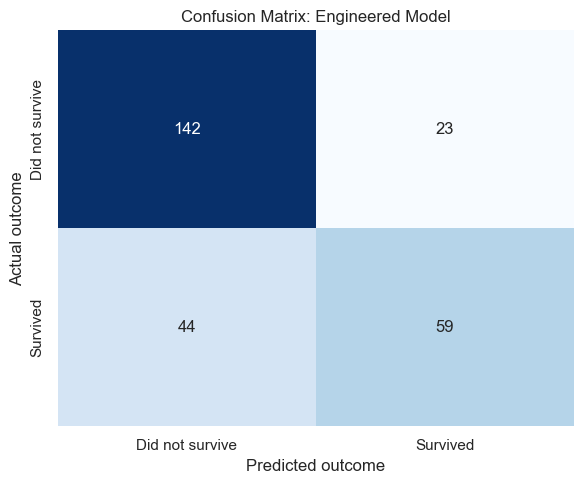


CONFUSION MATRIX
[[142  23]
 [ 44  59]]

Confusion-matrix interpretation:
The model correctly classifies 142 non-survivors and 59 survivors. It incorrectly labels 23 non-survivors as survivors and misses 44 passengers who survived.


In [17]:
# Confusion matrix:
# Rows contain the actual outcomes.
# Columns contain the predicted outcomes.
matrix = confusion_matrix(
    y_test,
    engineered_predictions,
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Did not survive",
        "Survived",
    ],
    yticklabels=[
        "Did not survive",
        "Survived",
    ],
)

plt.title("Confusion Matrix: Engineered Model")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

print("\nCONFUSION MATRIX")
print(matrix)

print(
    "\nConfusion-matrix interpretation:\n"
    "The model correctly classifies 142 non-survivors and 59 survivors. "
    "It incorrectly labels 23 non-survivors as survivors and misses "
    "44 passengers who survived."
)

## ROC curve:

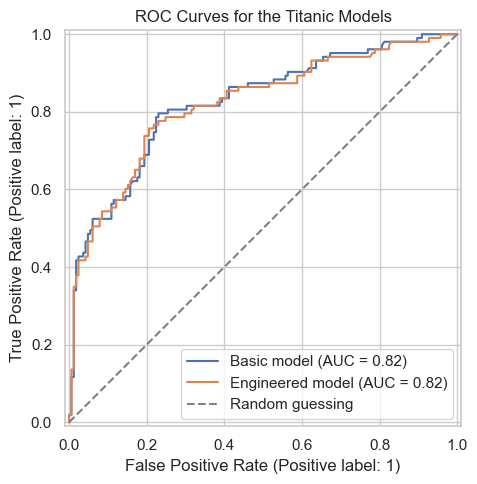


ROC-curve interpretation:
Both curves are above the random-guessing line. The basic model has a slightly larger area under the curve, so the family feature engineering did not improve how the model separates survivors and non-survivors on this test split.


In [18]:
# ROC curve:
# A curve closer to the upper-left corner represents a better model.
figure, axis = plt.subplots(figsize=(7, 5))

RocCurveDisplay.from_predictions(
    y_test,
    basic_probabilities,
    name="Basic model",
    ax=axis,
)

RocCurveDisplay.from_predictions(
    y_test,
    engineered_probabilities,
    name="Engineered model",
    ax=axis,
)

axis.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)

axis.set_title("ROC Curves for the Titanic Models")
axis.legend(loc="lower right")

plt.tight_layout()
plt.show()

print(
    "\nROC-curve interpretation:\n"
    "Both curves are above the random-guessing line. The basic model "
    "has a slightly larger area under the curve, so the family feature "
    "engineering did not improve how the model separates survivors "
    "and non-survivors on this test split."
)

## Examine the strongest coefficients:

In [19]:
# Examine the strongest coefficients:
# Match the prepared feature names with their fitted coefficients.
prepared_feature_names = (
    engineered_model
    .named_steps["prepare"]
    .get_feature_names_out()
)

coefficients = pd.Series(
    engineered_model.named_steps["model"].coef_[0],
    index=prepared_feature_names,
    name="Coefficient",
)

strongest_coefficients = (
    coefficients
    .to_frame()
    .assign(
        Absolute_size=lambda table:
        table["Coefficient"].abs()
    )
    .sort_values(
        "Absolute_size",
        ascending=False,
    )
    .head(12)
    .drop(columns="Absolute_size")
)

print("\nSTRONGEST MODEL COEFFICIENTS")
print(strongest_coefficients.to_string())

print(
    "\nCoefficient interpretation:\n"
    "Positive coefficients move a prediction toward survival. Negative "
    "coefficients move it toward non-survival. Sex, passenger class, "
    "and family size are among the model's strongest signals. These "
    "are associations and should not be treated as proof of causation."
)


STRONGEST MODEL COEFFICIENTS
                        Coefficient
categories__Sex_male         -1.482
categories__Sex_female        1.373
numbers__Pclass              -0.881
numbers__FamilySize          -0.742
numbers__Age                 -0.467
numbers__IsAlone             -0.435
categories__Embarked_Q        0.209
categories__Embarked_C       -0.163
categories__Embarked_S       -0.155
numbers__Fare                 0.140

Coefficient interpretation:
Positive coefficients move a prediction toward survival. Negative coefficients move it toward non-survival. Sex, passenger class, and family size are among the model's strongest signals. These are associations and should not be treated as proof of causation.


## Final conclusions:

In [20]:
# Final conclusions:
print(
    """
FINAL CONCLUSIONS

1. About 38% of the passengers in this dataset survived, so
   non-survivors are the larger group (which in itself is a bit problematic
   if the model is to be used for accurate predictions).

2. Female passengers had a much higher recorded survival rate than
   male passengers: about 74% compared with about 19%.

3. First-class passengers had the highest survival rate, while
   third-class passengers had the lowest survival rate.

4. Passengers traveling with at least one listed family member
   survived more often than passengers traveling alone.

5. The basic logistic regression model reached about 76% test
   accuracy and an ROC AUC of about 0.824.

6. Adding FamilySize and IsAlone did not improve this test result.
   The engineered model reached about 75.0% accuracy and a ROC AUC
   of about 0.820, slightly below the basic model.

7. The engineered model missed 44 actual survivors, so the model
   is useful for this theoretical exercise but I don't think it can be viably used for 
   any real-life situations. There are two many constraints, inaccuracies and simply the bias and context issues.

8. These results describe relationships in the historical data.
   They absolutely don't prove cause and effect (it would be a huge logical fallacy to assume they do)
   and should not be used to judge real people. 
"""
)


FINAL CONCLUSIONS

1. About 38% of the passengers in this dataset survived, so
   non-survivors are the larger group (which in itself is a bit problematic
   if the model is to be used for accurate predictions).

2. Female passengers had a much higher recorded survival rate than
   male passengers: about 74% compared with about 19%.

3. First-class passengers had the highest survival rate, while
   third-class passengers had the lowest survival rate.

4. Passengers traveling with at least one listed family member
   survived more often than passengers traveling alone.

5. The basic logistic regression model reached about 76% test
   accuracy and an ROC AUC of about 0.824.

6. Adding FamilySize and IsAlone did not improve this test result.
   The engineered model reached about 75.0% accuracy and a ROC AUC
   of about 0.820, slightly below the basic model.

7. The engineered model missed 44 actual survivors, so the model
   is useful for this theoretical exercise but I don't think it ca